# Assignment 3: Linear Models

In [1]:
! git clone https://github.com/kayleendo/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 30 (delta 5), reused 4 (delta 4), pack-reused 20 (from 1)
Receiving objects: 100% (30/30), 45.46 KiB | 15.15 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Download complete
Extracting data files...
Data extracted


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear if it is linear in its coefficients.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficiet of a one hot encoded variable represents a numeric value for a qualitative variable. Since one lineraly dependent column is dropped to avoid perfect multicolinearity, the intercept corresponds with the baseline group.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression can be used for classification, but it is not ideal. This is because linear regression can predict values outside of the range 0 and 1. Linear regression also assumes a continuous relationship rather than probabilities.

4. What are signs that your linear model is over-fitting?

A linear model that is over fitted performs well on training data but poorly on testing data. This means that the model has a low training error, but a high testing error.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicolinearity is when there are two or more predictor variables that are highly correlated with each other, which leads to highly correlated variables and unstable coefficie. The first stage is to regress the problematic predictor on all other variables in the regression and save the residuals. The second stage is to run a single linear regression. This approach seperates overlapping info between variables.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can incorporate nonlinear relationships by transforming inputs, such as adding polynomial terms, using transformations, and adding other variables.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient represents the average change in y for a one-unit increase in x. All other variables are kept constant.

8. Compare the train/test split and $k$-fold cross validation.

Data in a train test split is split once, and results depend on how the split is done. Data in k-fold is split into k parts, and the model is trained and tested k times using different splits.

9. How is the $k$ in $k$-fold cross validation typically selected?

K-fold cross validation is usually selected as k = 5 or 10. A high k value is slower, but has less bias. A low k value is faster, but has more bias.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [12]:
# Load data
df = pd.read_csv('/content/Q1_clean.csv')

# Clean column names
df.columns = df.columns.str.strip()

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive borough: Manhattan
Average price: 183.6642863215166


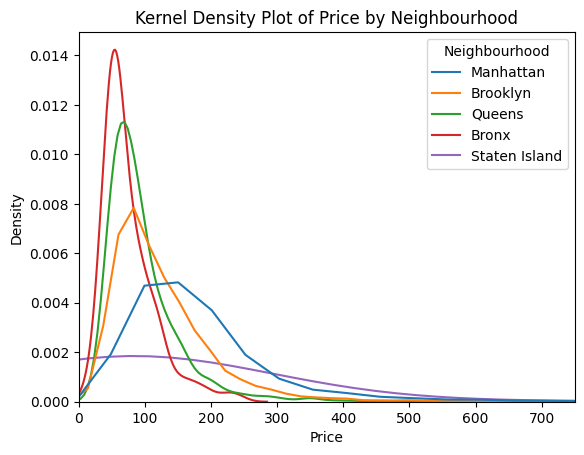

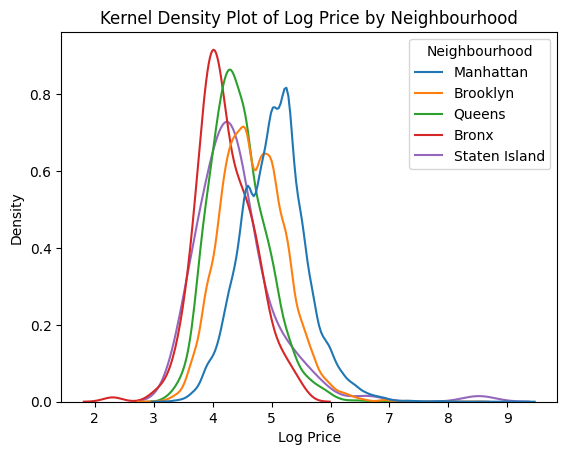

In [22]:
# Question 1
group_means = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()

# Print the table
print(group_means)

# Find the most expensive borough
most_expensive = group_means['Price'].idxmax()
highest_price = group_means['Price'].max()

print("Most expensive borough:", most_expensive)
print("Average price:", highest_price)

# Plot for score
plt.figure()
sns.kdeplot(data=df, x="Price", hue="Neighbourhood", common_norm=False)
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlim(0, 750)
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

# Plot for price
df["log_price"] = np.log(df["Price"])

plt.figure()
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood", common_norm=False)
plt.title("Kernel Density Plot of Log Price by Neighbourhood")
plt.xlabel("Log Price")
plt.ylabel("Density")
plt.show()

In [27]:
# Question 2

# Create dummy variables (drop first category)
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)

# Define X and y
X = dummies
y = df['Price']

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Get results
intercept = model.intercept_
coefficients = pd.Series(model.coef_, index=X.columns)

print("Intercept (baseline group mean):", intercept)
print("\nCoefficients:")
print(coefficients)

Intercept (baseline group mean): 75.27649769585331

Coefficients:
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


I decided to create the dummy variable by dropping the first category. The intercept represents the average price of the baseline neighbourhood. Each coefficient represents the difference in average price between that neighbourhood and the baseline. The regression coefficients match the differences in group means, meaning the model reproduces the conditional averages.

In [34]:
# Question 3

# Define X and y
X = df[['Review Scores Rating']]
y = df['Price']

# Fit model
model1 = LinearRegression()
model1.fit(X, y)

print("Intercept:", model1.intercept_)
print("Slope (Rating):", model1.coef_[0])

Intercept: 60.878390657123546
Slope (Rating): 1.0208266022674763


The slope coefficient represents the expected change in price for a one-point increase in review score. Specifically, a one-point increase in rating is associated with an average increase of β₁ dollars in price per night.

In [36]:
# Question 4

# Create dummies
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)

# Combine with rating
X2 = pd.concat([df[['Review Scores Rating']], dummies], axis=1)
y = df['Price']

# Fit model
model2 = LinearRegression()
model2.fit(X2, y)

print("Intercept:", model2.intercept_)
print("Coefficients:")
print(pd.Series(model2.coef_, index=X2.columns))

Intercept: -23.812561011673324
Coefficients:
Review Scores Rating      1.081116
Brooklyn                 51.704240
Manhattan               108.228737
Queens                   21.694600
Staten Island            71.766552
dtype: float64


After including neighbourhood controls, the coefficient on review scores increases, indicating that some of the relationship between rating and price was due to differences across neighbourhoods. The neighbourhood coefficients now represent differences in average prices after controlling for rating.

In [37]:
# Question 5

# Create dummies
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)

# Create interaction terms
for col in dummies.columns:
    dummies[col + "_x_rating"] = dummies[col] * df['Review Scores Rating']

# Combine everything
X3 = pd.concat([df[['Review Scores Rating']], dummies], axis=1)
y = df['Price']

# Fit model
model3 = LinearRegression()
model3.fit(X3, y)

print("Coefficients:")
print(pd.Series(model3.coef_, index=X3.columns))

Coefficients:
Review Scores Rating         0.574311
Brooklyn                   -16.392990
Manhattan                   41.315429
Queens                      28.259701
Staten Island             2963.071040
Brooklyn_x_rating            0.741165
Manhattan_x_rating           0.729703
Queens_x_rating             -0.072294
Staten Island_x_rating     -31.831748
dtype: float64


Allowing separate slopes for each neighbourhood shows whether the relationship between rating and price differs across boroughs. The slopes are pretty different, suggesting that ratings affect prices in a limited way across neighbourhoods.

In [38]:
# Question 6

def cross_val_mse(X, y, k=5):
    n = len(y)
    indices = np.arange(n)
    np.random.shuffle(indices)

    fold_size = n // k
    mses = []

    for i in range(k):
        start = i * fold_size
        end = start + fold_size

        test_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mse = np.mean((y_test - preds)**2)
        mses.append(mse)

    return np.mean(mses)

# Prepare datasets
X1 = df[['Review Scores Rating']]
X2 = pd.concat([df[['Review Scores Rating']], pd.get_dummies(df['Neighbourhood'], drop_first=True)], axis=1)

# X3 (interaction)
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)
for col in dummies.columns:
    dummies[col + "_x_rating"] = dummies[col] * df['Review Scores Rating']
X3 = pd.concat([df[['Review Scores Rating']], dummies], axis=1)

y = df['Price']

# Compute CV errors
print("Model 4 (Rating only):", cross_val_mse(X1, y))
print("Model 5 (Rating + Neighbourhood):", cross_val_mse(X2, y))
print("Model 6 (Interaction):", cross_val_mse(X3, y))

Model 4 (Rating only): 22085.920642878078
Model 5 (Rating + Neighbourhood): 21081.32199374197
Model 6 (Interaction): 21376.012897099048


Cross-validation results show that adding neighbourhood variables improves model performance compared to using rating alone.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


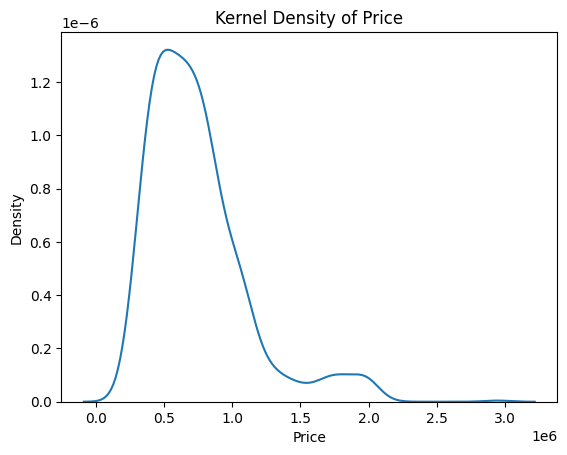

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


In [11]:
# Question 1

# Load data
df = pd.read_csv('/content/data/cars_hw.csv')

# Summarize
print(df["Price"].describe())

sns.kdeplot(df["Price"])
plt.title("Kernel Density of Price")
plt.show()

print(df.groupby("Body_Type")["Price"].describe())

SUVs are the most expensive and has the most variance

In [13]:
# Question 2
X = df[["Seating_Capacity"]]
y = df["Price"]

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]

print("Slope:", slope)

X_cat = pd.get_dummies(df["Seating_Capacity"], drop_first=True)
y = df["Price"]

model_cat = LinearRegression()
model_cat.fit(X_cat, y)

print("Coefficients:", model_cat.coef_)

Slope: 59267.99803672175
Coefficients: [ 546483.87096774 1456000.          735948.71794872  271800.        ]


The slope coefficient tells us that for each additional seat in a car, the price increases by around $60,000. The relationship between number of seats and price iis not linear. Some seating jumps (ex. 4 to 5) increase in price sharply.

In [17]:
# Question 3

current_year = 2025
df["Age"] = current_year - df["Make_Year"]

# Cross validation
def kfold_cv(degree, X, y, k=10):
    n = len(X)
    indices = np.arange(n)
    np.random.shuffle(indices)

    fold_size = n // k
    errors = []

    for i in range(k):
        start = i * fold_size
        end = start + fold_size

        test_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # polynomial features
        X_train_poly = np.column_stack([X_train**d for d in range(1, degree+1)])
        X_test_poly = np.column_stack([X_test**d for d in range(1, degree+1)])

        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        preds = model.predict(X_test_poly)

        mse = np.mean((y_test - preds)**2)
        errors.append(mse)

    return np.mean(errors)

X_age = df["Age"].values
y = df["Price"].values

results = {}
for d in range(1, 6):
    results[d] = kfold_cv(d, X_age, y)

print(results)

best_degree = min(results, key=results.get)
print("Best degree:", best_degree)

{1: np.float64(97979051584.37718), 2: np.float64(97020938531.56815), 3: np.float64(97718129148.99184), 4: np.float64(97265428566.39929), 5: np.float64(94381606417.75064)}
Best degree: 5


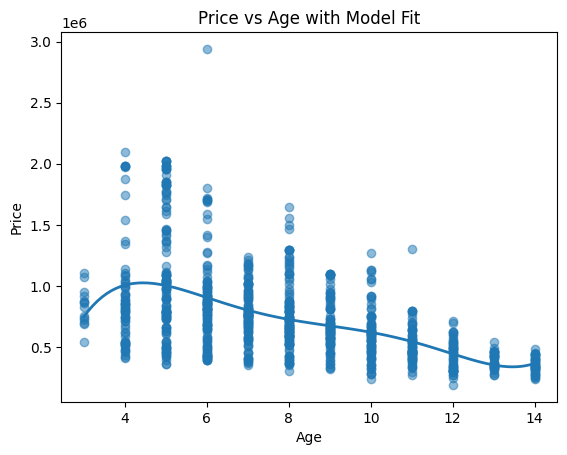

In [18]:
# Question 4
plt.scatter(df["Age"], df["Price"], alpha=0.5)

# Fit best model
X_poly = np.column_stack([X_age**d for d in range(1, best_degree+1)])
model = LinearRegression()
model.fit(X_poly, y)

# Smooth curve
age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 100)
age_grid_poly = np.column_stack([age_grid**d for d in range(1, best_degree+1)])

preds = model.predict(age_grid_poly)

plt.plot(age_grid, preds, linewidth=2)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Fit")
plt.show()

The model generally follos the patterns in the data because it aligns to the trend of the scatter points.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [4]:
# Load the data
df = pd.read_csv("/content/heart_hw.csv")

In [5]:
# Question 1
# A

control_survival = df[df["transplant"] == "control"]["y"].mean()
treatment_survival = df[df["transplant"] == "treatment"]["y"].mean()

ATE = treatment_survival - control_survival

control_survival, treatment_survival, ATE

(np.float64(0.11764705882352941),
 np.float64(0.34782608695652173),
 np.float64(0.23017902813299232))

The ATE on three-year survival is 23%

In [6]:
# Question 2
df["transplant_binary"] = (df["transplant"] == "treatment").astype(int)

X = df[["transplant_binary"]]
y = df["y"]

model1 = LinearRegression().fit(X, y)

intercept = model1.intercept_
coef = model1.coef_[0]

intercept, coef

(np.float64(0.1176470588235293), np.float64(0.23017902813299249))

The intercept quals the control group survival rate and the transpant coefficient equals the ATE.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


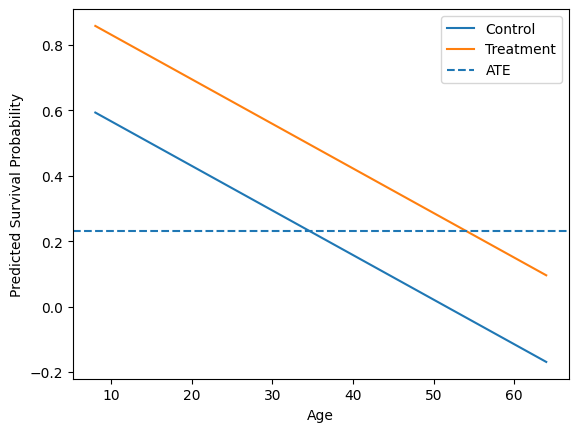

Intercept: 0.7019569721740947
Transplant coefficient: 0.2647016865036751
Age coefficient: -0.013607217160218647


In [15]:
# Question 3

X2 = df[["transplant_binary", "age"]]
model2 = LinearRegression().fit(X2, y)

model2.intercept_, model2.coef_

ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model2.predict(np.column_stack([np.zeros_like(ages), ages]))
pred_treat = model2.predict(np.column_stack([np.ones_like(ages), ages]))

plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treat, label="Treatment")

plt.axhline(ATE, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

print("Intercept:", model2.intercept_)
print("Transplant coefficient:", model2.coef_[0])
print("Age coefficient:", model2.coef_[1])


The transplant coefficient increases to 26% after we include age. This suggests that some of the original difference in survival rates was explained by age differences between groups. The intercept predicts the survival probability for a control patients, while the slope represents the difference in survival probability between treatment and control groups. Since the treatment and control lines are parallel, the effect of a transplant is consistent across ages. This means the ATE accurately represents the treatment effect for all ages.

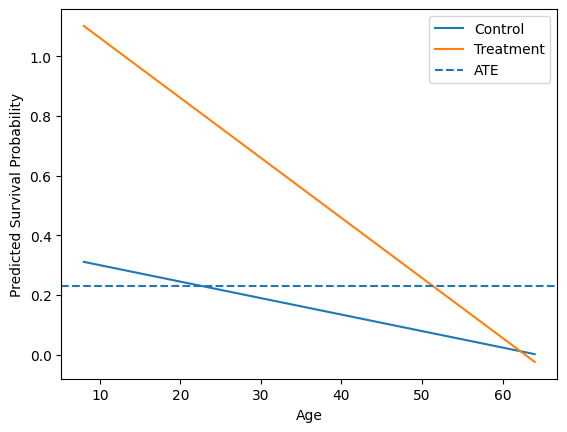

In [13]:
# Question 4

df["interaction"] = df["transplant_binary"] * df["age"]

X3 = df[["transplant_binary", "age", "interaction"]]
model3 = LinearRegression().fit(X3, y)

model3.intercept_, model3.coef_

ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model3.predict(pd.DataFrame({
    "transplant_binary": np.zeros_like(ages),
    "age": ages,
    "interaction": np.zeros_like(ages)
}))

pred_treat = model3.predict(pd.DataFrame({
    "transplant_binary": np.ones_like(ages),
    "age": ages,
    "interaction": ages
}))

plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treat, label="Treatment")

plt.axhline(ATE, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

Allowing age and transplant to interact allows the effect of transplant to change with age. This causes the slope of the treatment line to differ from the control. One pattern I notice is that once a patient is over the age of 65, the transplant effect is 0.

In [14]:
# Question 5

from sklearn.model_selection import cross_val_score

models = {
    "Model 1": LinearRegression(),
    "Model 2": LinearRegression(),
    "Model 3": LinearRegression()
}

X1 = df[["transplant_binary"]]
X2 = df[["transplant_binary", "age"]]
X3 = df[["transplant_binary", "age", "interaction"]]

scores1 = -cross_val_score(models["Model 1"], X1, y, cv=10, scoring="neg_mean_squared_error").mean()
scores2 = -cross_val_score(models["Model 2"], X2, y, cv=10, scoring="neg_mean_squared_error").mean()
scores3 = -cross_val_score(models["Model 3"], X3, y, cv=10, scoring="neg_mean_squared_error").mean()

scores1, scores2, scores3

(np.float64(0.20970277289824915),
 np.float64(0.19922806049232317),
 np.float64(0.19609811380122735))

Question 6

One concern I have with using this model is selection bias. In reality, patients aren't randomly assigned transplants and sicker patients may be more likely to receive one. Another important factor to consider is that there are omitted variables, such as a patients health condition that need to be considered.